##### The idea of this notebook is to intersect the genebody obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [1]:
import pandas as pd
import pybedtools
from pybedtools import BedTool
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
for c in ["start1","end1","start2","end2"]:
    loops[c] = loops[c].astype(int)
loops[["chr1","start1","end1","chr2","start2","end2"]].to_csv(
    "all_loops.bedpe", sep="\t", index=False, header=False
)

In [3]:
# All the file loading
# Load genebody
genebody_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed")
genebody_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed")
# loops -mega ctrl + cpi
#loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
#loops = pd.DataFrame(loops)
# splitting loops to their anchors
#anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
#anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [3]:
#loops

In [4]:
# Extend genebody regions for somewhat good intersection
genebody_up_slop = genebody_up.slop(b=0,genome='hg38')
genebody_down_slop = genebody_down.slop(b=0,genome='hg38')

---

In [15]:
# anchor intersection only
# # === Step 1: Load loop table ===
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")

# # Reset index to ensure continuous numbering
# loops = loops.reset_index(drop=True)

# # Now create loop_id from the reset index
# loops["loop_id"] = loops.index.astype(str)

# # Ensure left-to-right loop span for same-chromosome loops
# loops["loop_chr"] = loops["chr1"]
# loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
# loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
# loops["loop_id"] = loops.index.astype(str)

# loop_spans = loops[["loop_chr", "loop_start", "loop_end", "loop_id"]]
# loop_bedtool = pybedtools.BedTool.from_dataframe(loop_spans)

# # === Step 2: Load gene body BED files ===
# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", sep="\t", header=None,
#                  names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", sep="\t", header=None,
#                    names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])
# genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# # === Step 3: Intersect loops spans with gene bodies ===
# intersected = loop_bedtool.intersect(genes_bed, u=True)

# # === Step 4: Get matching loop IDs and filter original loops ===
# matched_ids = [f.name for f in intersected]
# final_loops = loops[loops["loop_id"].isin(matched_ids)]

# # Check if any matched_ids are not in original loop_ids
# original_ids = set(loops["loop_id"].astype(str))
# matched_set = set(matched_ids)
# fake_ids = matched_set - original_ids
# if fake_ids:
#     print(f"WARNING: Found {len(fake_ids)} fake IDs: {list(fake_ids)[:5]}")

# # === Step 5: Write output in BEDPE (IGV-compatible) ===
# bedpe_cols = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
# final_loops[bedpe_cols].to_csv("loop_gene_combined_strategy.bedpe", sep="\t", header=False, index=False)


In [14]:
# loop span intersection only
# # Load loops and genes
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
# loops = loops.reset_index(drop=True)
# loops["loop_id"] = loops.index.astype(str)

# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", 
#                  sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", 
#                    sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])

# # Create loop anchors
# anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
# anchor1.columns = ["chr", "start", "end", "loop_id"]

# anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
# anchor2.columns = ["chr", "start", "end", "loop_id"]

# # Convert to BedTools
# anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
# anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)
# genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# # Find intersections
# intersect1 = anchor1_bed.intersect(genes_bed, u=True)
# intersect2 = anchor2_bed.intersect(genes_bed, u=True)

# # Get loop IDs that intersect with genes
# matched_ids1 = [f.name for f in intersect1]
# matched_ids2 = [f.name for f in intersect2]
# all_matched_ids = list(set(matched_ids1 + matched_ids2))

# # Filter and save
# final_loops = loops[loops["loop_id"].isin(all_matched_ids)]
# final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
#     "loop_gene_fixed.bedpe", sep="\t", header=False, index=False)

# print(f"Found {len(final_loops)} loops intersecting with genes (out of {len(loops)} total)")

In [13]:
#  # Same logic as before but instead of bedtools using pyranges for more readability
#  # Load loops and genes
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
# loops = loops.reset_index(drop=True)
# loops["loop_id"] = loops.index.astype(str)

# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", 
#                  sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", 
#                    sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])

# # Prepare loop anchors for intersection
# anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
# anchor1.columns = ["Chromosome", "Start", "End", "loop_id"]

# anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
# anchor2.columns = ["Chromosome", "Start", "End", "loop_id"]

# # Prepare genes for intersection
# genes_gr = pr.PyRanges(genes.rename(columns={"chr": "Chromosome", "start": "Start", "end": "End"}))

# # Convert anchors to PyRanges
# anchor1_gr = pr.PyRanges(anchor1)
# anchor2_gr = pr.PyRanges(anchor2)

# # Perform intersection
# intersect1 = anchor1_gr.join(genes_gr)
# intersect2 = anchor2_gr.join(genes_gr)

# # Get unique loop IDs with intersected genes
# matched_ids1 = intersect1.df["loop_id"].unique().tolist()
# matched_ids2 = intersect2.df["loop_id"].unique().tolist()
# all_matched_ids = list(set(matched_ids1 + matched_ids2))

# # Filter loops
# final_loops = loops[loops["loop_id"].isin(all_matched_ids)]

# # Save to BEDPE
# final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
#     "loop_gene_fixed.bedpe", sep="\t", header=False, index=False
# )

# print(f"Found {len(final_loops)} loops intersecting with genes (out of {len(loops)} total)")


In [5]:
# Load loops and gene bodies
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                 names=["chr", "start", "end", "gene_id", "score", "strand"])
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                   names=["chr", "start", "end", "gene_id", "score", "strand"])
genes = pd.concat([up, down])
genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# 1. Span intersection
loops["loop_chr"] = loops["chr1"]
loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
span_bed = pybedtools.BedTool.from_dataframe(
    loops[["loop_chr", "loop_start", "loop_end", "loop_id"]]
)

span_ids = {f.name for f in span_bed.intersect(genes_bed, u=True)}

# 2. Anchor intersection
anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
anchor1.columns = ["chr", "start", "end", "loop_id"]
anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
anchor2.columns = ["chr", "start", "end", "loop_id"]
anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)

anchor1_ids = {f.name for f in anchor1_bed.intersect(genes_bed, u=True)}
anchor2_ids = {f.name for f in anchor2_bed.intersect(genes_bed, u=True)}

# Combine all matches (union)
all_matched_ids = span_ids | anchor1_ids | anchor2_ids

# Filter and export
final_loops = loops[loops["loop_id"].isin(all_matched_ids)]
final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
    "loopspan&anchorbased_intersection_withgeneB.bedpe", sep="\t", header=False, index=False
)
print(f"Exported {len(final_loops)} loops where span OR either anchor overlaps a gene.")

Exported 1250 loops where span OR either anchor overlaps a gene.


In [6]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [9]:
final_loops

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,loop_chr,loop_start,loop_end
8,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,chr1,6105000,6245000
29,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,0.038743,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,chr1,9782500,9867500
71,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,0.010033,...,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,chr1,21222500,21577500
77,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,0.027536,...,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,chr1,22665000,22965000
78,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,0.030242,...,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,chr1,22672500,22887500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32165,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,0.011941,...,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,chr7,51412500,55607500
32208,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,0.015876,...,0.0298,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,chr8,94812500,95027500
32213,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,0.011803,...,0.0084,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,chr8,122735000,123065000
32230,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,0.032843,...,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,chr9,33582500,38557500


In [8]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

/tmp/ipykernel_3760501/4253765032.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(status_counts.index, rotation=45, ha='right')


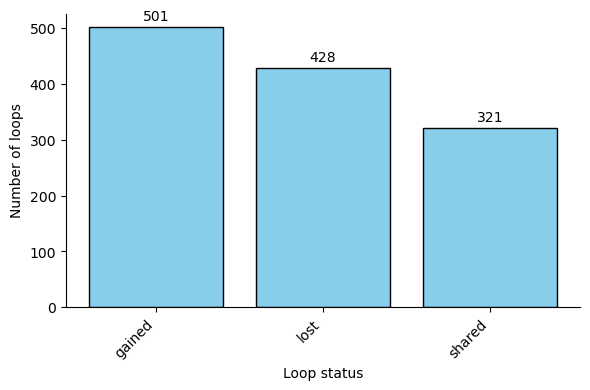

In [26]:
# Count the frequency of each status
status_counts = final_loops['status'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(status_counts.index, status_counts.values, color='skyblue', edgecolor='black')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Labels and formatting
#ax.set_title('Loop Status Distribution')
ax.set_xlabel('Loop status')
ax.set_ylabel('Number of loops')
ax.set_xticklabels(status_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3760501/3247746769.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(status_counts.index, rotation=45, ha='right')


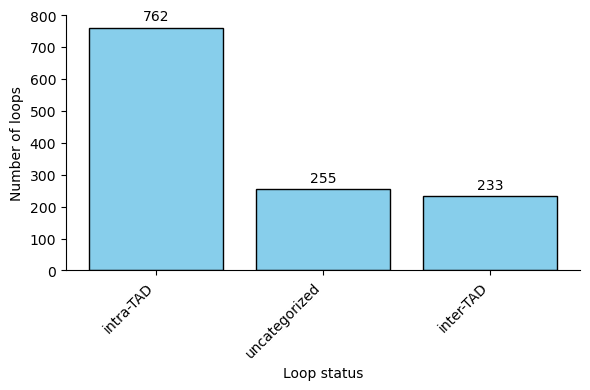

In [28]:
# Count the frequency of each status
status_counts = final_loops['loop_class'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(status_counts.index, status_counts.values, color='skyblue', edgecolor='black')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Labels and formatting
#ax.set_title('Loop Status Distribution')
ax.set_xlabel('Loop status')
ax.set_ylabel('Number of loops')
ax.set_xticklabels(status_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


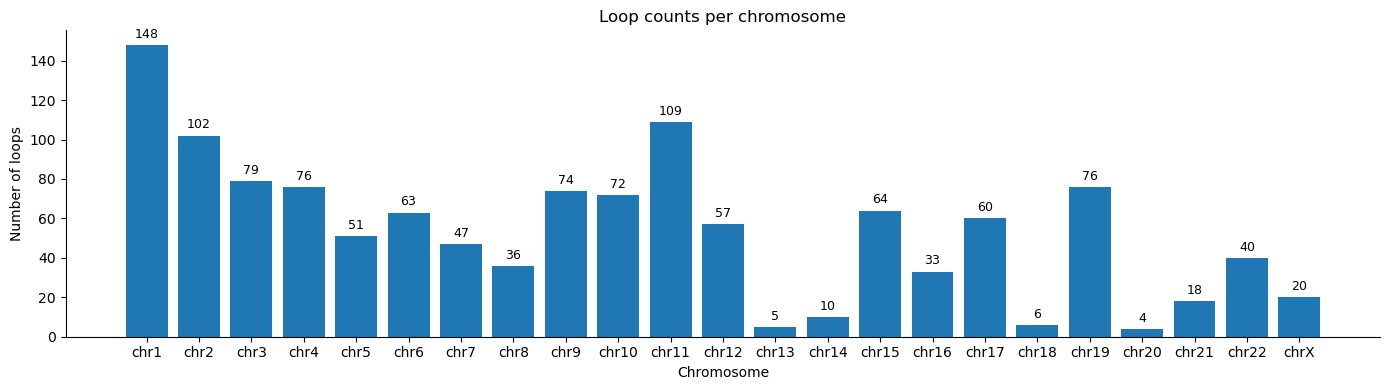

In [19]:
chrom_counts = final_loops['chr1'].value_counts()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
chrom_counts = chrom_counts.reindex(chrom_order, fill_value=0)

plt.figure(figsize=(14, 4))
bars = plt.bar(chrom_counts.index, chrom_counts.values)
plt.ylabel('Number of loops')
plt.xlabel('Chromosome')
plt.title('Loop counts per chromosome')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{int(height)}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=9
    )

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# signal_cols_main = ['CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal']

# # Melt data
# main_data = final_loops[signal_cols_main].melt(var_name='Signal', value_name='Value')
# main_data = main_data[main_data['Value'] > 0]

# # Subplots for each signal
# fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# for ax, signal in zip(axes.flatten(), signal_cols_main):
#     data = main_data[main_data['Signal'] == signal]
#     sns.violinplot(y='Value', data=data, ax=ax, inner='quartile', cut=0)
#     ax.set_yscale('log')
#     ax.set_title(signal)
#     ax.set_xlabel('')
#     ax.set_ylabel('Value')

# plt.tight_layout()
# plt.show()


In [11]:
### This code block is to export as before for `"loopspan&anchorbased_intersection_withgeneB.bedpe"` but with the associated gene info retained

# Load loops and gene bodies
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                 names=["chr", "start", "end", "gene_id", "score", "strand"])
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                   names=["chr", "start", "end", "gene_id", "score", "strand"])
genes = pd.concat([up, down])
genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# Loop span as BED
loops["loop_chr"] = loops["chr1"]
loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
span_bed = pybedtools.BedTool.from_dataframe(
    loops[["loop_chr", "loop_start", "loop_end", "loop_id"]]
)

# Anchor beds
anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
anchor1.columns = ["chr", "start", "end", "loop_id"]
anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
anchor2.columns = ["chr", "start", "end", "loop_id"]
anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)

# Function to intersect and retain gene info
def intersect_with_genes(loop_bed, label):
    res = loop_bed.intersect(genes_bed, wa=True, wb=True)
    df = res.to_dataframe(names=[
        'loop_chr', 'loop_start', 'loop_end', 'loop_id',
        'gene_chr', 'gene_start', 'gene_end', 'gene_id'
    ])
    df['region'] = label
    return df

span_hits = intersect_with_genes(span_bed, 'span')
a1_hits = intersect_with_genes(anchor1_bed, 'anchor1')
a2_hits = intersect_with_genes(anchor2_bed, 'anchor2')

# Combine all hits
all_hits = pd.concat([span_hits, a1_hits, a2_hits], ignore_index=True)
all_hits = all_hits.drop_duplicates(['loop_id', 'gene_id', 'region'])

# Aggregate genes per loop_id (comma-separated list)
gene_agg = all_hits.groupby('loop_id')['gene_id'].agg(lambda x: ','.join(sorted(set(x)))).reset_index()

# Ensure both loop_id columns are strings for merging
gene_agg['loop_id'] = gene_agg['loop_id'].astype(str)
loops['loop_id'] = loops['loop_id'].astype(str)

# Merge gene info back to loops
# Retain only loops with at least one intersecting gene
loops_with_genes = loops[loops["loop_id"].isin(gene_agg["loop_id"])]
loops_with_genes = loops_with_genes.merge(gene_agg, how='left', on='loop_id')

# Export
loops_with_genes.to_csv("loops_with_gene_info.csv", index=False)
print(f"Exported {len(loops_with_genes)} loops with gene information retained.")

Exported 1250 loops with gene information retained.


In [ ]:
import pandas as pd
import pybedtools

# Load loops
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

# Load gene body annotations (up & down)
up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                 names=["chr", "start", "end", "gene_id", "score", "strand"])
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", sep="\t", header=None,
                   names=["chr", "start", "end", "gene_id", "score", "strand"])
genes = pd.concat([up, down], ignore_index=True)

# Build BEDTool for intersection
genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# === change made ===
# Keep full gene chromosome info for correct merge later
genes_df = genes[["chr", "start", "end", "gene_id"]].copy()  # change made
genes_df.columns = ["gene_chr", "gene_start", "gene_end", "gene_id"]  # change made

# Prepare loop span
loops["loop_chr"] = loops["chr1"]
loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
span_bed = pybedtools.BedTool.from_dataframe(loops[["loop_chr", "loop_start", "loop_end", "loop_id"]])

# Prepare anchor beds
anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
anchor1.columns = ["chr", "start", "end", "loop_id"]
anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
anchor2.columns = ["chr", "start", "end", "loop_id"]
anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)

# Function to intersect and retain correct gene_chr info
def intersect_with_genes(loop_bed, label):
    res = loop_bed.intersect(genes_bed, wa=True, wb=True)
    
    # === change made ===
    # Placeholder column names for gene_chr; real info will be merged in
    df = res.to_dataframe(names=[
        'loop_chr', 'loop_start', 'loop_end', 'loop_id',
        '_gchr', '_gstart', '_gend', 'gene_id'  # change made
    ])
    
    # === change made ===
    # Merge real gene_chr info from source gene dataframe
    df = df.merge(genes_df, on='gene_id', how='left')  # change made
    
    # === change made ===
    # Keep only intra-chromosomal hits
    df = df[df['loop_chr'] == df['gene_chr']]  # change made

    df['region'] = label
    return df

# Perform intersections
span_hits = intersect_with_genes(span_bed, 'span')
a1_hits = intersect_with_genes(anchor1_bed, 'anchor1')
a2_hits = intersect_with_genes(anchor2_bed, 'anchor2')

# Combine all hits
all_hits = pd.concat([span_hits, a1_hits, a2_hits], ignore_index=True)
all_hits = all_hits.drop_duplicates(['loop_id', 'gene_id', 'region'])

# Aggregate gene assignments per loop
gene_agg = all_hits.groupby('loop_id')['gene_id'].agg(lambda x: ','.join(sorted(set(x)))).reset_index()

# Merge back to loops
loops['loop_id'] = loops['loop_id'].astype(str)
gene_agg['loop_id'] = gene_agg['loop_id'].astype(str)
loops_with_genes = loops[loops["loop_id"].isin(gene_agg["loop_id"])]
loops_with_genes = loops_with_genes.merge(gene_agg, how='left', on='loop_id')

# Export result
loops_with_genes.to_csv("loops_with_gene_info.cleaned.csv", index=False)
print(f"Exported {len(loops_with_genes)} loops with intra-chromosomal gene assignments.")
